# Baseline FC-AE: Raw ADC vs Log1p ADC

Test whether a simple fully connected autoencoder can reconstruct 7×7 TPC cluster patches, and compare raw ADC input with log-transformed ADC input.

中文说明：这个 notebook 只做一个 basic baseline autoencoder 实验。不要在这里做 cluster extraction，也不要声称 false signal detection performance，因为目前没有 ground-truth label。


## 1. Load Processed Patches

Load processed 7×7 raw patches from Notebook 1. The log input is loaded if available; otherwise it is generated as `log1p(raw)`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

SEED = 42
BATCH_SIZE = 64
N_EPOCHS = 150
LR = 1e-3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

np.random.seed(SEED)
torch.manual_seed(SEED)

RAW_PATCH_NPY = '/Users/amandadongsmacbookpro/Desktop/Gunther Research/Research/output/cluster_patches_7x7_raw.npy'
LOG_PATCH_NPY = '/Users/amandadongsmacbookpro/Desktop/Gunther Research/Research/output/cluster_patches_7x7_log.npy'

X_raw_np = np.load(RAW_PATCH_NPY).astype(np.float32)
try:
    X_log_np = np.load(LOG_PATCH_NPY).astype(np.float32)
    print('Loaded log1p patches from file.')
except FileNotFoundError:
    X_log_np = np.log1p(X_raw_np).astype(np.float32)
    print('Generated log1p patches from raw ADC.')

# Accept either (N, 49) or image-shaped arrays, then flatten to (N, 49).
X_raw_flat = X_raw_np.reshape(len(X_raw_np), -1).astype(np.float32)
X_log_flat = X_log_np.reshape(len(X_log_np), -1).astype(np.float32)

assert X_raw_flat.shape[1] == 49, X_raw_flat.shape
assert X_log_flat.shape == X_raw_flat.shape, (X_log_flat.shape, X_raw_flat.shape)

print(f'Raw input shape: {X_raw_flat.shape}')
print(f'Log input shape: {X_log_flat.shape}')
print(f'Device: {DEVICE}')


Loaded log1p patches from file.
Raw input shape: (3566, 49)
Log input shape: (3566, 49)
Device: cpu


## 2. Train Baseline FC-AE

Use the same architecture for both raw ADC and log1p ADC inputs:

`49 → 32 → 16 → 4 → 16 → 32 → 49`

The same random seed, train/validation split, optimizer, learning rate, epochs, and batch size are used for both models.


In [2]:
def make_loaders(X_np, batch_size=BATCH_SIZE):
    X = torch.tensor(X_np, dtype=torch.float32)
    dataset = TensorDataset(X)
    n_total = len(dataset)
    n_train = int(0.8 * n_total)
    n_val = n_total - n_train
    generator = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=generator)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=generator)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

raw_train_loader, raw_val_loader = make_loaders(X_raw_flat)
log_train_loader, log_val_loader = make_loaders(X_log_flat)

class BaselineFCAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(49, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 4),
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, 49), nn.ReLU(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_model(train_loader, val_loader, n_epochs=N_EPOCHS, lr=LR):
    model = BaselineFCAE().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {'train': [], 'val': []}

    for _ in range(n_epochs):
        model.train()
        train_loss = 0.0
        n_train = 0
        for (x,) in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(x), x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(x)
            n_train += len(x)

        model.eval()
        val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for (x,) in val_loader:
                x = x.to(DEVICE)
                loss = loss_fn(model(x), x)
                val_loss += loss.item() * len(x)
                n_val += len(x)

        history['train'].append(train_loss / n_train)
        history['val'].append(val_loss / n_val)

    return model, history

print('Training Raw ADC AE...')
model_raw, hist_raw = train_model(raw_train_loader, raw_val_loader)
print('Training Log1p ADC AE...')
model_log, hist_log = train_model(log_train_loader, log_val_loader)
print('Done.')


Training Raw ADC AE...
Training Log1p ADC AE...
Done.


## 3. Compare Training Behavior

Plot raw and log1p train/validation loss curves, then summarize final train and validation losses.


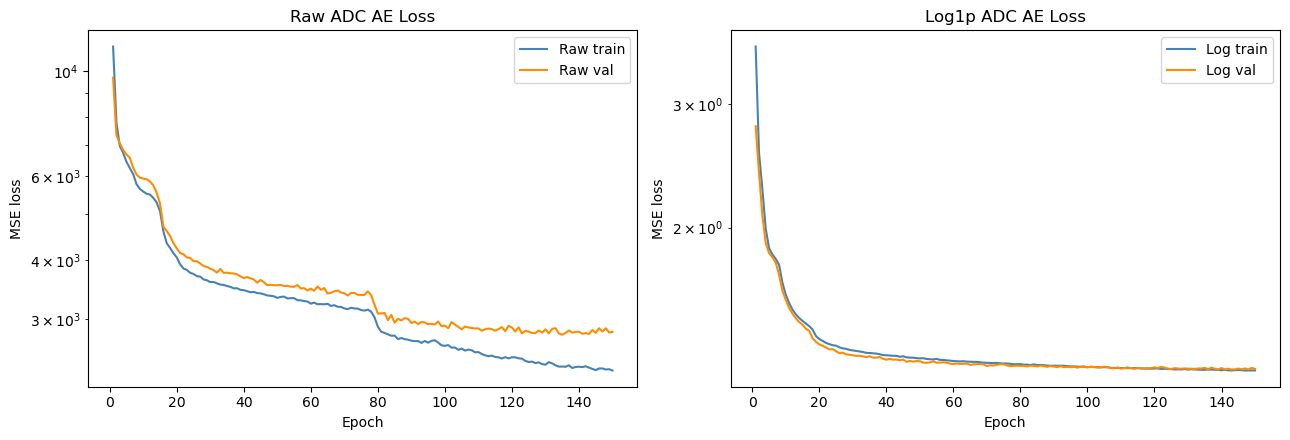

,final_train_loss,final_validation_loss
Raw ADC input,2340.335318,2823.696052
Log1p ADC input,1.252477,1.258878


In [3]:
epochs = np.arange(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs, hist_raw['train'], color='steelblue', label='Raw train')
axes[0].plot(epochs, hist_raw['val'], color='darkorange', label='Raw val')
axes[0].set_title('Raw ADC AE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE loss')
axes[0].set_yscale('log')
axes[0].legend()

axes[1].plot(epochs, hist_log['train'], color='steelblue', label='Log train')
axes[1].plot(epochs, hist_log['val'], color='darkorange', label='Log val')
axes[1].set_title('Log1p ADC AE Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE loss')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

loss_table = pd.DataFrame({
    'final_train_loss': [hist_raw['train'][-1], hist_log['train'][-1]],
    'final_validation_loss': [hist_raw['val'][-1], hist_log['val'][-1]],
}, index=['Raw ADC input', 'Log1p ADC input'])

display(loss_table.style.format('{:.6f}'))


## 4. Compare Reconstruction

Use the same patch indices for raw and log comparisons. For the log model, reconstructions are converted back to raw ADC scale using `expm1` before plotting.


In [4]:
X_raw_tensor = torch.tensor(X_raw_flat, dtype=torch.float32).to(DEVICE)
X_log_tensor = torch.tensor(X_log_flat, dtype=torch.float32).to(DEVICE)

model_raw.eval()
model_log.eval()
with torch.no_grad():
    recon_raw = model_raw(X_raw_tensor).cpu().numpy()
    recon_log_in_log_space = model_log(X_log_tensor).cpu().numpy()
    recon_log = np.clip(np.expm1(recon_log_in_log_space), 0, None)

raw_reconstruction_error = ((X_raw_flat - recon_raw) ** 2).mean(axis=1)
log_reconstruction_error = ((X_raw_flat - recon_log) ** 2).mean(axis=1)

comparison_table = pd.DataFrame({
    'final_train_loss': [hist_raw['train'][-1], hist_log['train'][-1]],
    'final_validation_loss': [hist_raw['val'][-1], hist_log['val'][-1]],
    'median_reconstruction_error_raw_ADC_space': [
        np.median(raw_reconstruction_error),
        np.median(log_reconstruction_error),
    ],
    'p95_reconstruction_error_raw_ADC_space': [
        np.percentile(raw_reconstruction_error, 95),
        np.percentile(log_reconstruction_error, 95),
    ],
}, index=['Raw ADC input', 'Log1p ADC input'])

display(comparison_table.style.format('{:.6f}'))


,final_train_loss,final_validation_loss,median_reconstruction_error_raw_ADC_space,p95_reconstruction_error_raw_ADC_space
Raw ADC input,2340.335318,2823.696052,92.127441,10596.783203
Log1p ADC input,1.252477,1.258878,131.697525,33879.686523


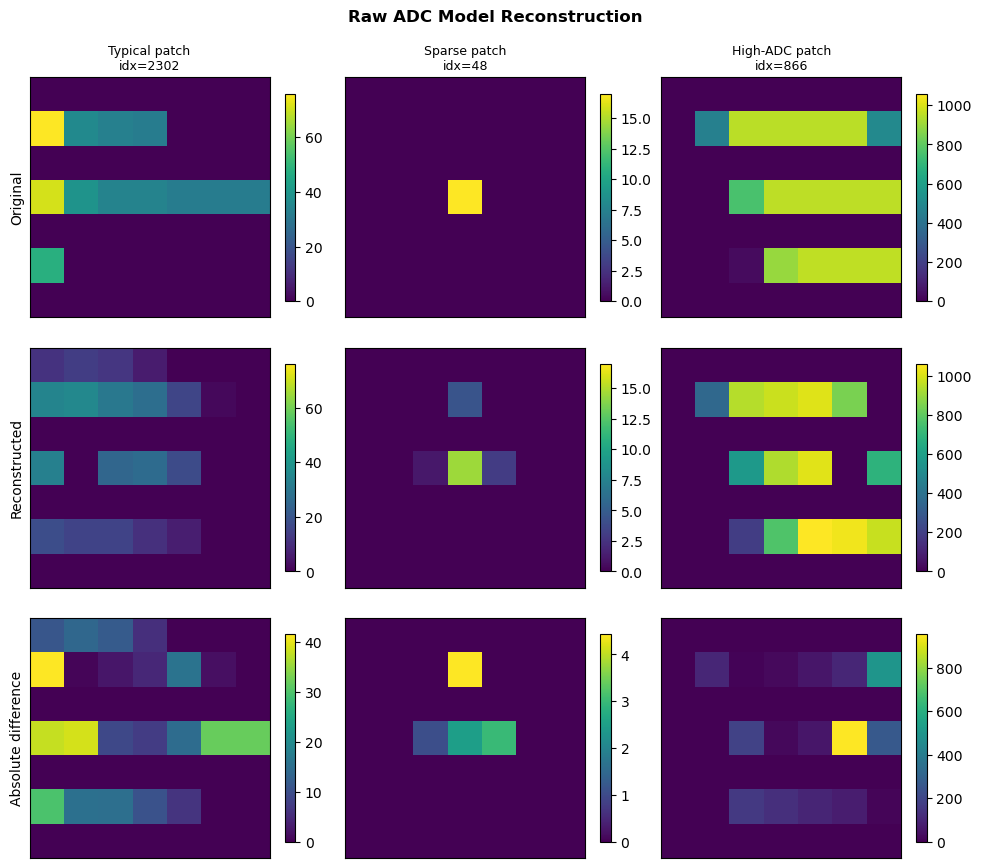

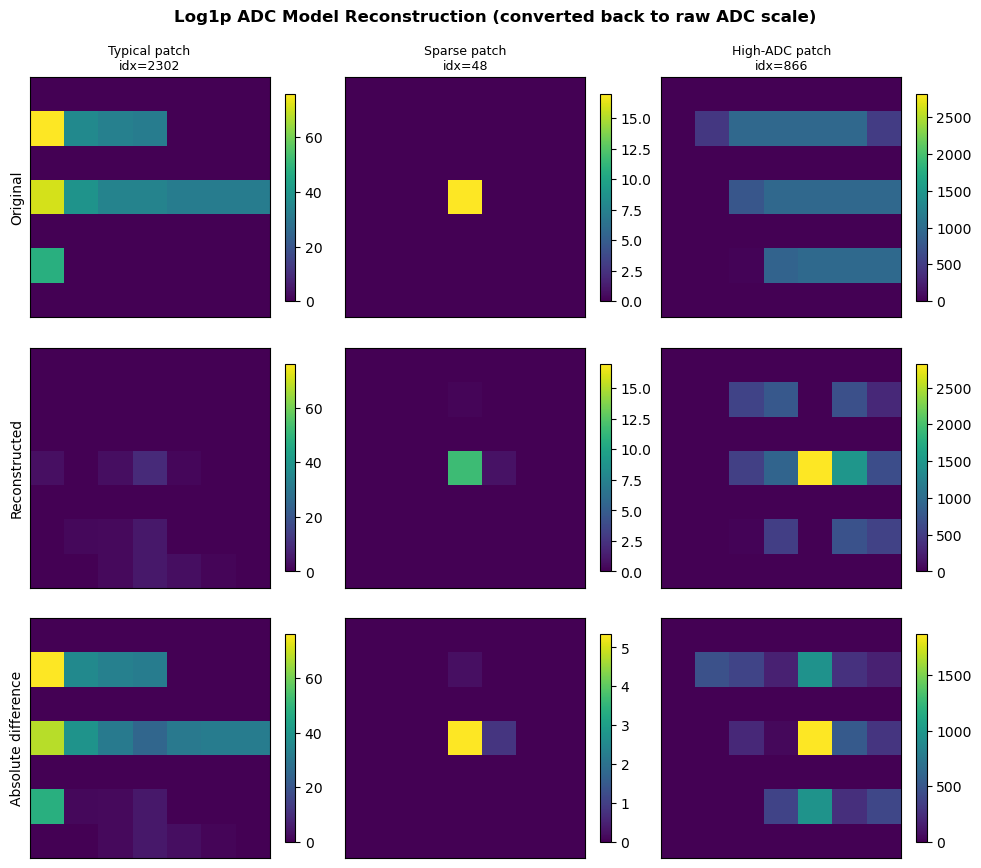

In [5]:
# Choose representative patch indices once, then reuse them for both models.
nonzero_count = (X_raw_flat > 0).sum(axis=1)
max_adc = X_raw_flat.max(axis=1)
sum_adc = X_raw_flat.sum(axis=1)
features = np.stack([nonzero_count, max_adc, sum_adc], axis=1).astype(float)
feature_median = np.median(features, axis=0)
feature_scale = features.std(axis=0) + 1e-8

typical_idx = int(np.linalg.norm((features - feature_median) / feature_scale, axis=1).argmin())
sparse_idx = int(nonzero_count.argmin())
high_adc_idx = int(max_adc.argmax())
selected_indices = [typical_idx, sparse_idx, high_adc_idx]
selected_labels = ['Typical patch', 'Sparse patch', 'High-ADC patch']

def plot_reconstruction_group(reconstruction, title):
    fig, axes = plt.subplots(3, 3, figsize=(10, 9))
    row_titles = ['Original', 'Reconstructed', 'Absolute difference']

    for col, (idx, label) in enumerate(zip(selected_indices, selected_labels)):
        original = X_raw_flat[idx]
        reconstructed = reconstruction[idx]
        diff = np.abs(original - reconstructed)
        vmax_img = max(float(original.max()), float(reconstructed.max()), 1.0)
        vmax_diff = max(float(diff.max()), 1.0)

        images = [original, reconstructed, diff]
        vmaxs = [vmax_img, vmax_img, vmax_diff]

        for row, (img, vmax) in enumerate(zip(images, vmaxs)):
            ax = axes[row, col]
            im = ax.imshow(img.reshape(7, 7), cmap='viridis', vmin=0, vmax=vmax, aspect='equal')
            if row == 0:
                ax.set_title(f'{label}\nidx={idx}', fontsize=9)
            if col == 0:
                ax.set_ylabel(row_titles[row])
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            fig.colorbar(im, ax=ax, shrink=0.75)

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_reconstruction_group(recon_raw, 'Raw ADC Model Reconstruction')
plot_reconstruction_group(recon_log, 'Log1p ADC Model Reconstruction (converted back to raw ADC scale)')


## 5. Short Interpretation

- Log1p may improve training stability by compressing the long ADC tail and reducing domination by a few high-ADC pixels.
- Raw ADC preserves the original amplitude scale more directly, which can be useful when absolute charge matters.
- Reconstruction errors above are reported in raw ADC space for a fair visual and numerical comparison.
- This notebook does **not** claim false signal detection performance because no ground-truth labels are available yet.

中文总结：现在这里只是 baseline reconstruction 实验，不是分类实验，也不是 anomaly/fake signal 判断。
